<a href="https://colab.research.google.com/github/DecioVdA/ProveComm/blob/main/Modelli/RandomForest_RidDispo_Fasce15min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Random Forest_RiduzioneDisponibilità

In questo esempio, al posto di analizzare solamente il totale giornaliero della targert feature.
Eliminerò quindi la variabile TransitiFRA, moltiplicherò il DataFrame per 96 valori gionralieri e concatenero' i dati Transiti su scaglioni di 15 minuti.

In [250]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import requests
from io import BytesIO
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

rd_seed = 42  # fissiamo un random seed per riproducibilità e replicabilità
np.random.seed(rd_seed)
random.seed(rd_seed)

rd_seed = 42

In [202]:
url = "https://github.com/DecioVdA/ProveComm/raw/refs/heads/main/DataSetAddestramento.xlsx"
response = requests.get(url)
df = pd.read_excel(BytesIO(response.content))

In [203]:
df.head()

,Data,GiornoSettimana,Scolastiche_VDA,Scolastiche_FRA,Scolastiche_CH,Festivo_ITA,Festivo_FRA,Festivo_CH,Dispo_TU,Dispo_Fre,TransitiFRA
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,2274
1,2024-01-02,Martedi,1,ABC,nullo,nullo,nullo,nullo,1.0,1.0,3160
2,2024-01-03,Mercoledi,1,ABC,nullo,nullo,nullo,nullo,1.0,1.0,2667
3,2024-01-04,Giovedi,1,ABC,nullo,nullo,nullo,nullo,1.0,1.0,2633
4,2024-01-05,Venerdi,1,ABC,nullo,nullo,nullo,nullo,1.0,1.0,2608


In [204]:
df = df.drop(['TransitiFRA'], axis= 1)
df.head()

,Data,GiornoSettimana,Scolastiche_VDA,Scolastiche_FRA,Scolastiche_CH,Festivo_ITA,Festivo_FRA,Festivo_CH,Dispo_TU,Dispo_Fre
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0
1,2024-01-02,Martedi,1,ABC,nullo,nullo,nullo,nullo,1.0,1.0
2,2024-01-03,Mercoledi,1,ABC,nullo,nullo,nullo,nullo,1.0,1.0
3,2024-01-04,Giovedi,1,ABC,nullo,nullo,nullo,nullo,1.0,1.0
4,2024-01-05,Venerdi,1,ABC,nullo,nullo,nullo,nullo,1.0,1.0


Espansione del dataframe per aggiungere 96 valori giornalieri.

In [205]:
def espansione_dataFrame(d_frame):
  row_espanse = []
  for idx, row in df.iterrows():
      for fascia in range(1, 97):  # da 1 a 96
          new_row = row.copy()
          new_row["FasciaOraria"] = fascia
          row_espanse.append(new_row)
  df_espanso = pd.DataFrame(row_espanse)
  return df_espanso


df = espansione_dataFrame(df)


In [206]:
df.head()

,Data,GiornoSettimana,Scolastiche_VDA,Scolastiche_FRA,Scolastiche_CH,Festivo_ITA,Festivo_FRA,Festivo_CH,Dispo_TU,Dispo_Fre,FasciaOraria
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,1
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,2
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,3
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,4
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,5


In [207]:
df.shape[0]

35136

In [208]:
df.shape[0] == (366*4*24) # 366 giorni di 24 ore moltiplicati per 4 fasce di analisi

True

Import dei dati di transito al dettaglio di 15 minuti e conversione in dataframe.

In [209]:
df_transiti = pd.read_csv("https://raw.githubusercontent.com/DecioVdA/ProveComm/refs/heads/main/data_fascia_oraria15minuti.csv", delimiter=';')

In [210]:
df_transiti.head()

,Année,Mois,Jour,Fascia_oraria_15m,Transiti
0,2024,janvier,1,00:00:00,6
1,2024,janvier,1,00:15:00,5
2,2024,janvier,1,00:30:00,5
3,2024,janvier,1,00:45:00,19
4,2024,janvier,1,01:00:00,10


Dato il periodo di chiusura, ci sono dei valori mancanti. Per esmpio alcuni mesi.


In [211]:
df_transiti.shape[0]

22290

In [212]:
ordine = df_transiti['Mois'].unique()
ordine = np.insert(ordine, 9, ['octobre', 'novembre'])
ordine = ordine[::-1]
fig = px.box(df_transiti, x = 'Transiti', y = 'Mois', color = 'Mois', title = 'Analisi Mensile degli Outliers')
fig.update_yaxes(categoryorder='array', categoryarray=ordine)
fig.show()

In [213]:
df_transiti['Fascia_oraria_15m'] = pd.to_timedelta(df_transiti['Fascia_oraria_15m'])
df_transiti['FasciaOraria'] = (df_transiti['Fascia_oraria_15m'].dt.total_seconds() / 60 / 15).astype(int) + 1
df_transiti = df_transiti.drop(['Fascia_oraria_15m'], axis = 1)
df_transiti.head()

,Année,Mois,Jour,Transiti,FasciaOraria
0,2024,janvier,1,6,1
1,2024,janvier,1,5,2
2,2024,janvier,1,5,3
3,2024,janvier,1,19,4
4,2024,janvier,1,10,5


In [214]:
df['Anno'] = df['Data'].dt.year
df['Mese'] = df['Data'].dt.month
df['Giorno'] = df['Data'].dt.day
df['GiornoAnno'] = df['Data'].dt.day_of_year
df = df.drop(['Data'], axis=1)


,GiornoSettimana,Scolastiche_VDA,Scolastiche_FRA,Scolastiche_CH,Festivo_ITA,Festivo_FRA,Festivo_CH,Dispo_TU,Dispo_Fre,FasciaOraria,Anno,Mese,Giorno,GiornoAnno
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,1,2024,1,1,1
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,2,2024,1,1,1
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,3,2024,1,1,1
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,4,2024,1,1,1
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,5,2024,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,Martedi,1,ABC,GVZ,nullo,nullo,nullo,1.0,1.0,92,2024,12,31,366
365,Martedi,1,ABC,GVZ,nullo,nullo,nullo,1.0,1.0,93,2024,12,31,366
365,Martedi,1,ABC,GVZ,nullo,nullo,nullo,1.0,1.0,94,2024,12,31,366
365,Martedi,1,ABC,GVZ,nullo,nullo,nullo,1.0,1.0,95,2024,12,31,366


In [215]:
mappa_giorni = {
    1:'Lunedi',
    2:'Martedi',
    3:'Mercoledi',
    4:'Giovedi',
    5:'Venerdi',
    6:'Sabato',
    7:'Domenica',
}

mappa_mesi = {
    1:'janvier',
    2:'février',
    3:'mars',
    4:'avril',
    5:'mai',
    6:'juin',
    7:'juillet',
    8:'août',
    9:'septembre',
    10:'octobre',
    11:'novembre',
    12:'décembre'
}

df_transiti['GiornoSettimana'] = df_transiti['Jour'].map(mappa_giorni)
df['mois'] = df['Mese'].map(mappa_mesi)

In [218]:
df_transiti = df_transiti.rename(columns={
    "Année": "Anno",
    "Mois": "mois",
    "Jour": "Giorno"
})


df_merged = df.merge(
    df_transiti,
    on=["Anno", "mois", "Giorno", "FasciaOraria"],
    how="left"
)

In [219]:
df_merged.shape[0]

35136

In [221]:
df_merged = df_merged.drop(['Data'], axis = 1)
df_merged = df_merged.drop(['GiornoSettimana_x'], axis = 1)
df_merged = df_merged.drop(['Mese'], axis = 1)
df_merged = df_merged.drop(['Giorno'], axis = 1)
df_merged = df_merged.drop(['GiornoAnno'], axis = 1)
df_merged = df_merged.drop(['Anno'], axis = 1)
df_merged['Scolastiche_VDA'] = df_merged['Scolastiche_VDA'].replace({1: 'Si', 0:'No'})

In [222]:
df_merged = df_merged.rename(columns={"GiornoSettimana_y": "Giorno"})

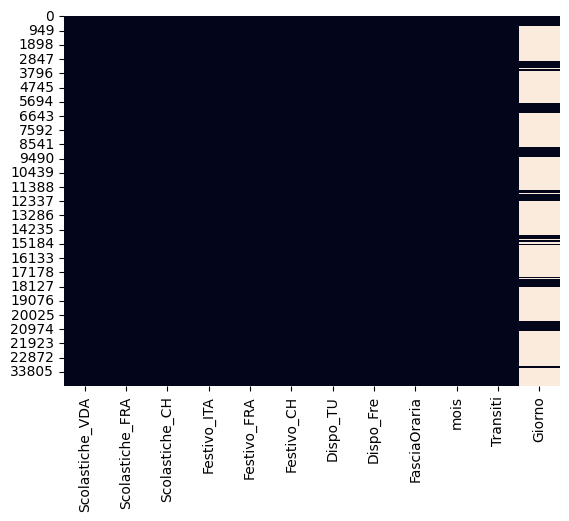

In [258]:
missing_values = df_merged
sns.heatmap(missing_values.isnull(), cbar = False)
plt.show()

Elimino i valori per Dispo_TU = 0

In [264]:
df_merged = df_merged[df_merged["Dispo_TU"] > 0].copy()
df_merged['Transiti'] = df_merged['Transiti'].fillna(0)
# df_merged = df_merged.drop(['Giorno'], axis = 1)

In [265]:
df_merged.shape[0]

24672

In [266]:
df_merged.isnull().sum()

,0
Scolastiche_VDA,0
Scolastiche_FRA,0
Scolastiche_CH,0
Festivo_ITA,0
Festivo_FRA,0
Festivo_CH,0
Dispo_TU,0
Dispo_Fre,0
FasciaOraria,0
mois,0


In [267]:
df_merged['FasciaOraria'] = df_merged['FasciaOraria'].astype(str)

In [268]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24672 entries, 0 to 35135
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Scolastiche_VDA  24672 non-null  object 
 1   Scolastiche_FRA  24672 non-null  object 
 2   Scolastiche_CH   24672 non-null  object 
 3   Festivo_ITA      24672 non-null  object 
 4   Festivo_FRA      24672 non-null  object 
 5   Festivo_CH       24672 non-null  object 
 6   Dispo_TU         24672 non-null  float64
 7   Dispo_Fre        24672 non-null  float64
 8   FasciaOraria     24672 non-null  object 
 9   mois             24672 non-null  object 
 10  Transiti         24672 non-null  float64
dtypes: float64(3), object(8)
memory usage: 2.3+ MB


In [269]:
categoriche = ['Scolastiche_VDA','Scolastiche_FRA','Scolastiche_CH','Festivo_ITA', 'Festivo_FRA', 'Festivo_CH', 'FasciaOraria', 'mois']
numeriche = list(set(df_merged.columns)- set(df_merged[categoriche]) - {'Transiti'})

Suddivisone del dataframe in training e test


In [270]:
X = df_merged.drop(['Transiti'], axis = 1)
y = df_merged['Transiti']

In [271]:
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=rd_seed)

In [272]:
encoder = OneHotEncoder().fit(X_train[categoriche])

X_train_cat_enc = encoder.transform(X_train[categoriche]).todense().astype(int)
X_train_cat_enc = pd.DataFrame(X_train_cat_enc, columns = encoder.get_feature_names_out(categoriche), index = X_train.index)

X_test_cat_enc = encoder.transform(X_test[categoriche]).todense().astype(int)
X_test_cat_enc = pd.DataFrame(X_test_cat_enc, columns = encoder.get_feature_names_out(categoriche), index = X_test.index)


In [273]:
X_train = pd.concat([X_train[numeriche], X_train_cat_enc], axis=1)
X_test = pd.concat([X_test[numeriche], X_test_cat_enc], axis=1)

In [274]:
model = RandomForestRegressor(random_state = rd_seed)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [275]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [276]:

print("MAE train:", mean_absolute_error(y_train, y_pred_train))
print("MAE test:", mean_absolute_error(y_test, y_pred_test))

print("RMSE train:", mean_squared_error(y_train, y_pred_train))
print("RMSE test:", mean_squared_error(y_test, y_pred_test))

print("R2 train:", r2_score(y_train, y_pred_train))
print("R2 test:", r2_score(y_test, y_pred_test))

MAE train: 10.9868644933992
MAE test: 15.063809099538725
RMSE train: 306.6290191705789
RMSE test: 486.0186372407651
R2 train: 0.8323611921195654
R2 test: 0.7282541937466709


In [277]:
imps = pd.DataFrame()
imps['Variabile'] = X_train.columns
imps['Importanza'] = model.feature_importances_
imps = imps.sort_values('Importanza')
px.bar(imps, x = 'Variabile', y = 'Importanza')